# 08 — nth Roots; Rational Exponents

**Topic 8 of the math journey.** Here we learn how to *undo* powers.

## Intuition first

You already know powers: $2^3 = 8$ means "multiply three 2's".
A **root** asks the reverse question:

> *"What number, raised to the power $n$, gives me $a$?"*

- The **square root** $\sqrt{9}=3$ because $3^2=9$.
- The **cube root** $\sqrt[3]{8}=2$ because $2^3=8$.
- In general the **$n$th root** $\sqrt[n]{a}$ is a number whose $n$th power is $a$.

Then comes a beautiful idea. Instead of writing a new symbol $\sqrt[n]{a}$,
we can write it as a **power with a fraction**:

$$\sqrt[n]{a} = a^{1/n}, \qquad \sqrt[n]{a^m} = a^{m/n}.$$

This is not a trick. We will **prove** that fractional exponents obey the *same*
laws as the whole-number exponents you learned in Topic 2. Roots and powers become
one single idea.

**Why this matters for AI.** Roots are everywhere in machine learning: the length
(norm) of a vector is a square root, the *root* mean square (RMS) error is a square
root, standard deviation is a square root, and many learning-rate schedules decay
like $1/\sqrt{t}$. You cannot read an AI paper without fractional powers.


## 0. Warm-up: active recall (spaced repetition)

Before new material, answer these from memory (solutions at the bottom of §3):

1. **(Topic 7 — cancellation / domain).** Simplify $\dfrac{x^2-9}{x^2-x-6}$ and state
   the excluded values. Where is the *hole* and where is the *vertical asymptote*?
2. **(Topic 5 — factoring).** Factor $x^3-8$ completely. *(Hint: difference of cubes.)*
3. **(Topic 1 — the lingering weak spot).** Convert the repeating decimal
   $0.\overline{27}$ to a fraction. Show the $10^k$-shift trick.

Write your answers in the cell below, then check yourself later.


In [1]:
# Your warm-up answers (write them here, then check §3):
# 1.
# 2.
# 3.


## 1. Formal definitions

> **Definition (nth root).** Let $n\ge 1$ be an integer and $a$ a real number.
> A real number $x$ is an **$n$th root of $a$** if
> $$x^n = a.$$

A number can have several real $n$th roots, or none:

- $9$ has **two** square roots: $3$ and $-3$ (both square to $9$).
- $-4$ has **no** real square root (a square is never negative).
- $8$ has exactly **one** real cube root: $2$.

To get a single, predictable answer we choose one special root.

> **Definition (principal $n$th root, the radical $\sqrt[n]{\,}$).**
> - If $n$ is **odd**, then for every real $a$ there is exactly one real $n$th root;
>   we write it $\sqrt[n]{a}$.
> - If $n$ is **even**, then for $a\ge 0$ we define $\sqrt[n]{a}$ to be the
>   **non-negative** $n$th root, and for $a<0$ the symbol $\sqrt[n]{a}$ is **undefined**
>   in the real numbers.
>
> The symbol $\sqrt[n]{\,}$ is called a **radical**, $a$ is the **radicand**, and
> $n$ is the **index**. When $n=2$ we drop the index and write $\sqrt{a}$.

So by definition the principal root is the *one* root we are allowed to call
"*the*" root, and for even index it is the non-negative one. Example: $\sqrt{9}=3$
(never $-3$), but $-3$ is still *an* $n$th root of $9$.

> **Definition (rational exponent).** Let $a>0$ and let $\tfrac{m}{n}$ be a fraction
> with integer $m$ and integer $n\ge 1$. We define
> $$a^{1/n} := \sqrt[n]{a}, \qquad a^{m/n} := \left(\sqrt[n]{a}\right)^{m}.$$
> We also keep $a^{0}=1$ and $a^{-r}=\dfrac{1}{a^{r}}$ as in Topic 2.
>
> For $a=0$ we set $0^{r}=0$ when $r>0$. For $a<0$ we only allow $a^{m/n}$ when
> $n$ is **odd** (then $\sqrt[n]{a}$ exists); otherwise it is undefined in $\mathbb{R}$.

The whole point of the next section is to show these definitions are **safe**:
the value $a^{m/n}$ does not depend on *how* we write the fraction, and the old
exponent laws still hold.


## 2. Theorems, proved in full

Throughout, "number" means real number. We lean on two earlier facts:

- **Integer-exponent laws** (Topic 2): $x^{p}x^{q}=x^{p+q}$, $(x^{p})^{q}=x^{pq}$,
  $(xy)^{p}=x^{p}y^{p}$ for integers $p,q$.
- **Completeness of $\mathbb{R}$** (Topic 1): every non-empty set bounded above has a
  least upper bound (supremum).

### Lemma A — powers are strictly increasing on $[0,\infty)$

> **Lemma A.** If $0\le x<y$ and $n\ge 1$, then $x^n<y^n$.

**Proof.** We use the factorisation (a finite geometric-type identity)
$$y^n-x^n=(y-x)\,(y^{n-1}+y^{n-2}x+\cdots+x^{n-1}).$$
You can check it by expanding the right side: the sum telescopes. Now $y-x>0$.
Every term in the second bracket is $\ge 0$ because $x,y\ge0$, and the leading term
$y^{n-1}>0$ since $y>x\ge0$ means $y>0$. So the bracket is $>0$. A product of two
positive numbers is positive, hence $y^n-x^n>0$, i.e. $x^n<y^n$. $\blacksquare$

A direct consequence: on $[0,\infty)$ the map $x\mapsto x^n$ is **one-to-one**, so a
non-negative $a$ can have **at most one** non-negative $n$th root. That gives
*uniqueness*. Now existence.

### Theorem 1 — existence & uniqueness of the principal root

> **Theorem 1.** For every real $a\ge 0$ and integer $n\ge 1$ there is **exactly one**
> real number $x\ge 0$ with $x^n=a$.

**Proof.** *Uniqueness* is Lemma A (two different non-negative numbers have different
$n$th powers). For *existence* we build $x$ with completeness. Define the set
$$S=\{\,t\ge 0 : t^n\le a\,\}.$$
$S$ is non-empty because $0\in S$ ($0^n=0\le a$). $S$ is bounded above by $a+1$:
if $t>a+1\ge1$ then $t^n\ge t> a$ (using Lemma A and $t\ge1\Rightarrow t^n\ge t$),
so such $t$ is not in $S$. By **completeness** the supremum $x=\sup S$ exists, and
$x\ge0$. We claim $x^n=a$ by ruling out the two other cases.

*Case $x^n<a$ (show $x$ is not really the top).* Pick a small $h$ with $0<h\le1$.
Then
$$(x+h)^n = \sum_{k=0}^{n}\binom{n}{k}x^{n-k}h^{k}
          \le x^n + h\sum_{k=1}^{n}\binom{n}{k}x^{n-k}
          = x^n + h\,C,$$
where $C=\sum_{k=1}^{n}\binom{n}{k}x^{n-k}$ is a fixed positive number (we used
$h^k\le h$ for $0<h\le1$). If we choose $h$ small enough that $h\,C< a-x^n$ (and
$h\le1$), then $(x+h)^n<a$, so $x+h\in S$. But $x+h>x=\sup S$ — impossible. So
$x^n<a$ cannot happen.

*Case $x^n>a$ (show $x$ is too big).* For $0<h<x$,
$$x^n-(x-h)^n \le h\sum_{k=1}^{n}\binom{n}{k}x^{n-k}=h\,C$$
by the same binomial bound. Choose $h$ with $h\,C<x^n-a$; then $(x-h)^n>a$. By
Lemma A every $t\ge x-h$ has $t^n\ge(x-h)^n>a$, so no element of $S$ exceeds $x-h$:
that makes $x-h$ an upper bound smaller than $x=\sup S$ — impossible. So $x^n>a$
cannot happen.

The only surviving case is $x^n=a$. $\blacksquare$

For **odd** $n$ and $a<0$ existence follows by symmetry: $\sqrt[n]{a}=-\sqrt[n]{-a}$,
because $(-y)^n=-y^n$ when $n$ is odd.


### Theorem 2 — the laws of radicals

The cleanest way to prove root identities is the **"raise both sides to the $n$"**
method, justified by the *uniqueness* in Theorem 1: if two non-negative numbers have
the same $n$th power, they are equal.

> **Theorem 2.** Let $a,b\ge0$ and let $m,n\ge1$ be integers. Then
> 1. $\big(\sqrt[n]{a}\big)^{n}=a$ and $\sqrt[n]{a^{n}}=a$;
> 2. $\sqrt[n]{ab}=\sqrt[n]{a}\,\sqrt[n]{b}$ *(product rule)*;
> 3. $\sqrt[n]{\dfrac{a}{b}}=\dfrac{\sqrt[n]{a}}{\sqrt[n]{b}}$ for $b>0$ *(quotient rule)*;
> 4. $\sqrt[m]{\sqrt[n]{a}}=\sqrt[mn]{a}$ *(root of a root)*;
> 5. $\sqrt[n]{a^{m}}=\big(\sqrt[n]{a}\big)^{m}$.

**Proof.**

**(1)** By definition $\sqrt[n]{a}$ is the number whose $n$th power is $a$; that *is*
the statement $(\sqrt[n]{a})^n=a$. For $\sqrt[n]{a^n}$: the number $a\ge0$ satisfies
$a^n=a^n$ and is non-negative, so by uniqueness it is the principal root, i.e.
$\sqrt[n]{a^n}=a$.

**(2)** Let $x=\sqrt[n]{a}$ and $y=\sqrt[n]{b}$; both are $\ge0$, so $xy\ge0$. Using the
integer law $(xy)^n=x^ny^n$ (Topic 2),
$$(xy)^n=x^n y^n=a\,b.$$
Thus $xy$ is a non-negative number whose $n$th power is $ab$. By the **uniqueness** in
Theorem 1, $xy=\sqrt[n]{ab}$. That is exactly (2).

**(3)** Same idea with $x=\sqrt[n]{a}$, $y=\sqrt[n]{b}>0$: $(x/y)^n=x^n/y^n=a/b\ge0$,
and $x/y\ge0$, so $x/y=\sqrt[n]{a/b}$.

**(4)** Let $z=\sqrt[m]{\sqrt[n]{a}}\ge0$. Then $z^m=\sqrt[n]{a}$, so
$(z^m)^n=a$. By the integer law $(z^m)^n=z^{mn}$, hence $z^{mn}=a$ with $z\ge0$;
uniqueness gives $z=\sqrt[mn]{a}$.

**(5)** Let $x=\sqrt[n]{a}\ge0$. Then $x^m\ge0$ and $(x^m)^n=x^{mn}=(x^n)^m=a^m$, so
$x^m$ is the non-negative number whose $n$th power is $a^m$; by uniqueness
$x^m=\sqrt[n]{a^m}$. $\blacksquare$


### Theorem 3 — the $\sqrt{a^2}=|a|$ trap

A square root undoes a square **only up to sign**. This is the single most common
mistake, so we prove it.

> **Theorem 3.** For every real $a$, $\quad\sqrt{a^{2}}=|a|.$

**Proof.** Recall $|a|\ge0$ for all $a$, and $|a|^2=a^2$ (whether $a\ge0$ or $a<0$,
because $(-a)^2=a^2$). So $|a|$ is a *non-negative* number whose square is $a^2$. By
the uniqueness of the principal square root (Theorem 1), $\sqrt{a^2}=|a|$.
$\blacksquare$

So $\sqrt{(-5)^2}=\sqrt{25}=5=|-5|$, **not** $-5$. More generally, for even index
$\sqrt[n]{a^n}=|a|$, while for odd index $\sqrt[n]{a^n}=a$ (sign is kept).


### Theorem 4 — rational exponents are well defined

We *defined* $a^{m/n}=(\sqrt[n]{a})^m$. But the same rational number has many names:
$\tfrac{2}{3}=\tfrac{4}{6}$. The definition is only honest if it gives the **same value**
no matter which name we use.

> **Theorem 4 (well-definedness).** Let $a>0$. If $\dfrac{m}{n}=\dfrac{p}{q}$ (with
> $n,q\ge1$), then $\big(\sqrt[n]{a}\big)^{m}=\big(\sqrt[q]{a}\big)^{p}.$

**Proof.** Both sides are positive (a positive base to an integer power). Raise each to
the power $nq$ and compare; if two positive numbers have equal $nq$-th powers they are
equal (uniqueness, Theorem 1). Left side:
$$\Big(\big(\sqrt[n]{a}\big)^{m}\Big)^{nq}=\big(\sqrt[n]{a}\big)^{mnq}
 =\Big(\big(\sqrt[n]{a}\big)^{n}\Big)^{mq}=a^{mq}.$$
Right side, the same way:
$$\Big(\big(\sqrt[q]{a}\big)^{p}\Big)^{nq}=\big(\sqrt[q]{a}\big)^{pnq}
 =\Big(\big(\sqrt[q]{a}\big)^{q}\Big)^{pn}=a^{pn}.$$
Now $\dfrac{m}{n}=\dfrac{p}{q}$ means $mq=pn$, so $a^{mq}=a^{pn}$. The two $nq$-th powers
agree, therefore the two sides agree. $\blacksquare$

> **Corollary.** $a^{m/n}=\sqrt[n]{a^{m}}=\big(\sqrt[n]{a}\big)^{m}$ for $a>0$ — this is
> Theorem 2(5). So "root first then power" equals "power first then root".


### Theorem 5 — the exponent laws survive for rational powers

> **Theorem 5.** For $a,b>0$ and rational numbers $r,s$:
> $$a^{r}a^{s}=a^{r+s},\qquad \frac{a^{r}}{a^{s}}=a^{r-s},\qquad
> (a^{r})^{s}=a^{rs},\qquad (ab)^{r}=a^{r}b^{r}.$$

**Proof.** Write $r=\dfrac{p}{n}$ and $s=\dfrac{q}{n}$ over a **common denominator**
$n\ge1$ (always possible), and put $\alpha=\sqrt[n]{a}>0$, $\beta=\sqrt[n]{b}>0$, so
$a=\alpha^{n}$, $b=\beta^{n}$, $a^{r}=\alpha^{p}$, $a^{s}=\alpha^{q}$ (using the
Corollary). Everything reduces to **integer** exponent laws from Topic 2.

*Product:* $a^{r}a^{s}=\alpha^{p}\alpha^{q}=\alpha^{p+q}=a^{(p+q)/n}=a^{r+s}.$

*Quotient:* $\dfrac{a^{r}}{a^{s}}=\dfrac{\alpha^{p}}{\alpha^{q}}=\alpha^{p-q}=a^{(p-q)/n}=a^{r-s}.$

*Power of a power:* $(a^{r})^{s}=(\alpha^{p})^{q/n}$. Let $\gamma=\sqrt[n]{\alpha^{p}}$,
so $(\alpha^{p})^{s}=\gamma^{q}$. Raise to the $n$: $(\gamma^{q})^{n}=(\gamma^{n})^{q}
=(\alpha^{p})^{q}=\alpha^{pq}$, and also $\big(a^{rs}\big)^{n}=\big(\alpha^{pq/n}\big)^{n}
=\alpha^{pq}$ by the Corollary. Both sides are positive with equal $n$th powers, so by
uniqueness $(a^{r})^{s}=a^{rs}$.

*Product base:* $(ab)^{r}$. Let $\delta=\sqrt[n]{ab}>0$; by Theorem 2(2)
$\delta=\alpha\beta$, so $(ab)^{r}=\delta^{p}=(\alpha\beta)^{p}=\alpha^{p}\beta^{p}
=a^{r}b^{r}$. $\blacksquare$

This is the payoff: **fractional exponents are just exponents.** Every algebra rule you
know keeps working, which is why we can freely write $\sqrt[n]{a}=a^{1/n}$.


### Simplest radical form & rationalizing

Two standard "clean-up" skills, both consequences of Theorem 2.

**Simplest radical form** pulls out perfect $n$th-power factors:
$$\sqrt{72}=\sqrt{36\cdot 2}=\sqrt{36}\,\sqrt{2}=6\sqrt{2},
\qquad \sqrt[3]{54}=\sqrt[3]{27\cdot2}=3\sqrt[3]{2}.$$
A radical is "simplest" when the radicand has no perfect-$n$th-power factor, no
fractions, and no radical sits in a denominator.

**Rationalizing the denominator** removes a root from the bottom by multiplying by a
clever form of $1$:
$$\frac{1}{\sqrt{2}}=\frac{1}{\sqrt{2}}\cdot\frac{\sqrt{2}}{\sqrt{2}}=\frac{\sqrt{2}}{2},
\qquad
\frac{1}{\sqrt{3}-1}=\frac{1}{\sqrt{3}-1}\cdot\frac{\sqrt{3}+1}{\sqrt{3}+1}
=\frac{\sqrt{3}+1}{(\sqrt3)^2-1^2}=\frac{\sqrt{3}+1}{2}.$$
The second uses the **conjugate** $\sqrt3+1$ and the difference-of-squares identity
$(x-y)(x+y)=x^2-y^2$ from Topic 4 — the radical disappears because squaring kills it.


## 3. Worked examples (by hand)

**Example A — evaluate.** $\;\displaystyle 8^{2/3}.$
$$8^{2/3}=\big(\sqrt[3]{8}\big)^{2}=2^{2}=4.$$
Or "power first": $8^{2/3}=\sqrt[3]{8^{2}}=\sqrt[3]{64}=4.$ Same answer (Theorem 4).

**Example B — negative exponent.** $\;\displaystyle 16^{-3/4}
=\frac{1}{16^{3/4}}=\frac{1}{(\sqrt[4]{16})^{3}}=\frac{1}{2^{3}}=\frac{1}{8}.$

**Example C — simplify with the laws.**
$$\frac{x^{1/2}\,x^{1/3}}{x^{1/6}}=x^{\,1/2+1/3-1/6}=x^{\,3/6+2/6-1/6}=x^{4/6}=x^{2/3}
\quad(x>0).$$

**Example D — simplest radical form.**
$\;\sqrt{50}+\sqrt{18}=5\sqrt2+3\sqrt2=8\sqrt2.$

**Example E — rationalize.**
$\;\dfrac{6}{\sqrt5+\sqrt2}=\dfrac{6(\sqrt5-\sqrt2)}{(\sqrt5)^2-(\sqrt2)^2}
=\dfrac{6(\sqrt5-\sqrt2)}{3}=2(\sqrt5-\sqrt2).$

**Example F — the sign trap.** $\;\sqrt{(x-3)^2}=|x-3|$, **not** $x-3$. It equals
$x-3$ only when $x\ge3$.

---

### Solutions to the §0 warm-up

1. $\dfrac{x^2-9}{x^2-x-6}=\dfrac{(x-3)(x+3)}{(x-3)(x+2)}=\dfrac{x+3}{x+2}$, with excluded
   values $x\ne3$ and $x\ne-2$. The cancelled factor $x-3$ gives a **hole** at $x=3$;
   the surviving denominator factor gives a **vertical asymptote** at $x=-2$.
2. $x^3-8=(x-2)(x^2+2x+4)$. The quadratic has discriminant $4-16<0$, so it does not
   factor further over $\mathbb{R}$.
3. Let $x=0.\overline{27}$. Two repeating digits $\Rightarrow$ shift by $10^2$:
   $100x=27.\overline{27}=27+x$, so $99x=27$, $x=\dfrac{27}{99}=\dfrac{3}{11}$.


## 4. Python demonstrations

We use **sympy** (exact symbolic algebra), **numpy** (fast numeric arrays) and
**matplotlib** (plots). Every math-library line has a comment in plain language.


In [2]:
import sympy as sp           # sympy = exact symbolic math (keeps roots exact)
import numpy as np            # numpy = fast numeric arrays / float math
import matplotlib.pyplot as plt   # matplotlib = plotting

sp.init_printing()           # pretty-print sympy expressions
print("libraries loaded")


libraries loaded


In [3]:
# --- nth roots, exactly and numerically -----------------------------------
print(sp.sqrt(9))            # exact principal square root -> 3
print(sp.root(8, 3))         # exact cube root of 8 -> 2  (sp.root(x, n) = n-th root)
print(sp.root(54, 3))        # sympy auto-simplifies to 3*2**(1/3) (simplest radical form)
print(sp.sqrt(72))           # -> 6*sqrt(2): perfect-square factor 36 pulled out

# numeric (float) values with numpy
print(np.power(8.0, 1/3))    # 8**(1/3) as a float -> ~2.0
print(np.sqrt(2.0))          # square root of 2 -> 1.41421356...


3
2
3*2**(1/3)
6*sqrt(2)
2.0
1.4142135623730951


In [4]:
# --- a number has several nth roots; the radical picks the principal one ---
# All real square roots of 9 are +3 and -3, but sqrt(9) is defined as +3.
x = sp.symbols('x')
print(sp.solve(sp.Eq(x**2, 9), x))   # [-3, 3]  : both square roots
print(sp.sqrt(9))                    # 3        : the PRINCIPAL (non-negative) one

# Cube root of a negative number IS real (odd index): cbrt(-8) = -2
print(sp.real_root(-8, 3))           # real_root forces the real cube root -> -2


[-3, 3]
3
-2


In [5]:
# --- Theorem 2 (laws of radicals) checked numerically ----------------------
a, b, n = 7.0, 3.0, 4
lhs = (a*b)**(1/n)                       # n-th root of (a*b)
rhs = a**(1/n) * b**(1/n)                # (n-th root a)*(n-th root b)
print("product rule:", np.isclose(lhs, rhs), lhs, rhs)

lhs2 = (a/b)**(1/n)                      # n-th root of (a/b)
rhs2 = a**(1/n) / b**(1/n)
print("quotient rule:", np.isclose(lhs2, rhs2))

# root of a root:  m-th root of (n-th root of a) == (m*n)-th root of a
m = 3
print("root of a root:", np.isclose((a**(1/n))**(1/m), a**(1/(m*n))))


product rule: True 2.1406951429280725 2.140695142928072
quotient rule: True
root of a root: True


In [6]:
# --- Theorem 4: a^(m/n) does NOT depend on how we write the fraction -------
a = sp.Integer(8)
print(sp.nsimplify(a**sp.Rational(2, 3)))   # 8**(2/3)
print(sp.nsimplify(a**sp.Rational(4, 6)))   # 8**(4/6) -- same fraction, same value -> 4

# "root first" equals "power first":
print((sp.root(8, 3))**2, sp.root(8**2, 3)) # both 4


4
4
4 4


In [7]:
# --- Theorem 3: the sign trap  sqrt(a**2) = |a|, NOT a ---------------------
for a in [5, -5, 0]:
    print(f"a={a:>2}:  sqrt(a**2) = {np.sqrt(a**2):>3}   |a| = {abs(a)}")

# sympy keeps it honest only if it knows the sign:
x = sp.symbols('x', real=True)
print(sp.sqrt(x**2))                 # -> Abs(x)   (sympy returns |x|, not x)
xpos = sp.symbols('xpos', positive=True)
print(sp.sqrt(xpos**2))              # -> xpos     (safe to drop bars when x>0)


a= 5:  sqrt(a**2) = 5.0   |a| = 5
a=-5:  sqrt(a**2) = 5.0   |a| = 5
a= 0:  sqrt(a**2) = 0.0   |a| = 0
Abs(x)
xpos


In [8]:
# --- Rationalizing the denominator with sympy ------------------------------
expr = 6 / (sp.sqrt(5) + sp.sqrt(2))
print("before:", expr)
print("after :", sp.radsimp(expr))   # radsimp = rationalize: -> 2*sqrt(5) - 2*sqrt(2)

expr2 = 1 / (sp.sqrt(3) - 1)
print(sp.radsimp(expr2))             # -> sqrt(3)/2 + 1/2


before: 6/(sqrt(2) + sqrt(5))
after : -2*sqrt(2) + 2*sqrt(5)
(1 + sqrt(3))/2


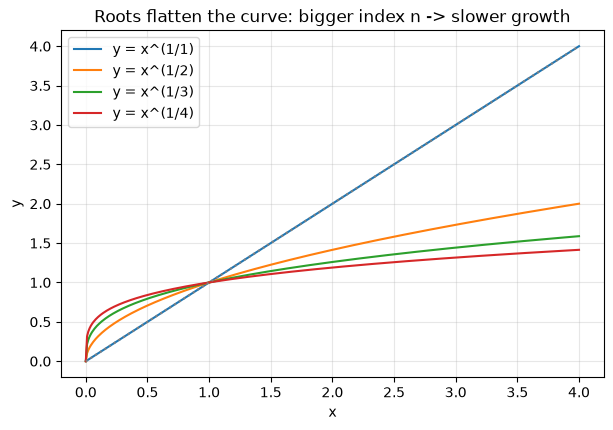

In [9]:
# --- Plot y = x^(1/n) for a few indices ------------------------------------
xs = np.linspace(0, 4, 400)          # 400 x-values from 0 to 4
plt.figure(figsize=(7, 4.5))
for n in [1, 2, 3, 4]:
    plt.plot(xs, xs**(1/n), label=f"y = x^(1/{n})")  # the n-th root curve
plt.plot(xs, xs, ':', color='gray')  # reference line y = x
plt.title("Roots flatten the curve: bigger index n -> slower growth")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


In [10]:
# --- AI / numerics hook: Newton's method for the n-th root of A ------------
# To compute A**(1/n) without a built-in root, solve f(x)=x**n - A = 0.
# Newton iteration:  x <- x - f(x)/f'(x) = ((n-1)*x + A/x**(n-1)) / n
def nth_root_newton(A, n, iters=20):
    x = A / n + 1.0                       # any positive starting guess
    for _ in range(iters):
        x = ((n - 1) * x + A / x**(n - 1)) / n   # one Newton step
    return x

print(nth_root_newton(2, 2), np.sqrt(2))          # ~1.41421356 == sqrt(2)
print(nth_root_newton(50, 3), 50**(1/3))          # cube root of 50
# This is exactly how a CPU/GPU computes roots inside ML libraries.


1.414213562373095 1.4142135623730951
3.684031498640387 3.6840314986403864


## 5. Where this shows up in AI

Fractional powers are not abstract — you meet them on page one of machine learning:

- **Vector length / $L^2$ norm.** $\;\lVert v\rVert=\sqrt{v_1^2+\cdots+v_d^2}=\big(\sum v_i^2\big)^{1/2}$.
  This is the Euclidean distance from Topic 3, now written as a power $1/2$.
- **$L^p$ norms.** $\;\lVert v\rVert_p=\big(\sum |v_i|^p\big)^{1/p}$ — a root with a
  general index $p$.
- **RMS error / standard deviation.** Both are square roots of an average of squares.
- **Learning-rate schedules.** Many optimizers decay the step size like
  $\eta_t=\eta_0/\sqrt{t}$, i.e. $t^{-1/2}$.
- **Adam / RMSProp** divide gradients by $\sqrt{\text{(running mean of squares)}}$.

So the harmless-looking $a^{1/n}$ is a daily tool, not a museum piece.


## 6. Exercises (you fill these in)

Twenty problems, easy → hard, ending in proofs. Try each by hand first, then you may
check with sympy. Write your work in the cell under each prompt.


**Exercise 1 — Easy — evaluate.**  
Compute by hand: (a) $\sqrt{49}$, (b) $\sqrt[3]{125}$, (c) $\sqrt[4]{16}$, (d) $\sqrt[3]{-27}$.

In [11]:
# Exercise 1: your work here


**Exercise 2 — Easy — radical or undefined?**  
Which of these are real numbers? $\sqrt{-9}$, $\sqrt[3]{-9}$, $\sqrt[4]{-1}$, $\sqrt[5]{-32}$. Explain each in one sentence.

In [12]:
# Exercise 2: your work here


**Exercise 3 — Easy — rational exponent form.**  
Rewrite using radicals, then evaluate: (a) $27^{1/3}$, (b) $81^{1/4}$, (c) $32^{1/5}$.

In [13]:
# Exercise 3: your work here


**Exercise 4 — Easy — power/root mix.**  
Evaluate: (a) $8^{2/3}$, (b) $25^{3/2}$, (c) $16^{-1/2}$.

In [14]:
# Exercise 4: your work here


**Exercise 5 — Easy — to exponent form.**  
Write as a single power of $x$ (assume $x>0$): (a) $\sqrt{x}$, (b) $\sqrt[5]{x^3}$, (c) $\dfrac{1}{\sqrt[3]{x}}$.

In [15]:
# Exercise 5: your work here


**Exercise 6 — Medium — simplest radical form.**  
Simplify: (a) $\sqrt{75}$, (b) $\sqrt{200}$, (c) $\sqrt[3]{16}$, (d) $\sqrt[3]{250}$.

In [16]:
# Exercise 6: your work here


**Exercise 7 — Medium — combine like radicals.**  
Simplify: (a) $\sqrt{12}+\sqrt{27}$, (b) $5\sqrt{8}-\sqrt{18}$, (c) $\sqrt[3]{54}-\sqrt[3]{16}$.

In [17]:
# Exercise 7: your work here


**Exercise 8 — Medium — laws of exponents.**  
Simplify to one power (assume variables $>0$): (a) $x^{1/2}\cdot x^{1/3}$, (b) $\dfrac{y^{3/4}}{y^{1/4}}$, (c) $\big(z^{2/3}\big)^{6}$.

In [18]:
# Exercise 8: your work here


**Exercise 9 — Medium — multiply radicals.**  
Multiply and simplify: (a) $\sqrt{6}\,\sqrt{15}$, (b) $\sqrt[3]{4}\,\sqrt[3]{2}$, (c) $\sqrt{2}\,(\sqrt{8}-\sqrt{2})$.

In [19]:
# Exercise 9: your work here


**Exercise 10 — Medium — rationalize (single term).**  
Rationalize the denominator: (a) $\dfrac{3}{\sqrt{5}}$, (b) $\dfrac{2}{\sqrt[3]{4}}$, (c) $\sqrt{\dfrac{7}{3}}$.

In [20]:
# Exercise 10: your work here


**Exercise 11 — Medium — rationalize (conjugate).**  
Rationalize: (a) $\dfrac{4}{\sqrt{7}-\sqrt{3}}$, (b) $\dfrac{\sqrt{5}}{\sqrt{5}+2}$.

In [21]:
# Exercise 11: your work here


**Exercise 12 — Medium — the sign trap.**  
Simplify, keeping it correct for ALL real $x$: (a) $\sqrt{x^2}$, (b) $\sqrt{(x-4)^2}$, (c) $\sqrt[3]{x^3}$, (d) $\sqrt[4]{x^4}$.

In [22]:
# Exercise 12: your work here


**Exercise 13 — Medium — solve.**  
Solve for real $x$: (a) $x^{2}=20$, (b) $x^{3}=-64$, (c) $x^{2/3}=9$. List ALL real solutions.

In [23]:
# Exercise 13: your work here


**Exercise 14 — Harder — mixed simplify.**  
Simplify (variables $>0$): (a) $\dfrac{x^{1/2}\,x^{1/3}}{x^{1/6}}$, (b) $\big(8x^{6}\big)^{2/3}$, (c) $\sqrt{\dfrac{50x^{3}}{2x}}$.

In [24]:
# Exercise 14: your work here


**Exercise 15 — Harder — compare without a calculator.**  
Which is larger, $\sqrt[3]{2}$ or $\sqrt{2}$? Justify using Lemma A / the laws (a common index helps).

In [25]:
# Exercise 15: your work here


**Exercise 16 — Harder — nested radical.**  
Show that $\sqrt{3+2\sqrt{2}}=1+\sqrt{2}$. (Hint: square the right-hand side.) Then state why we take $+(1+\sqrt2)$ and not $-(1+\sqrt2)$.

In [26]:
# Exercise 16: your work here


**Exercise 17 — Harder — evaluate carefully.**  
Compute $\big((-8)^{2}\big)^{1/2}$ and $\big((-8)^{1/2}\big)^{2}$. Are they equal? Explain why the law $(a^r)^s=a^{rs}$ needs $a>0$.

In [27]:
# Exercise 17: your work here


**Exercise 18 — Proof.**  
Prove the product rule $\sqrt[n]{ab}=\sqrt[n]{a}\,\sqrt[n]{b}$ for $a,b\ge0$, using uniqueness of the principal $n$th root (Theorem 1). Write every step.

_Write your proof here:_



**Exercise 19 — Proof.**  
Prove that $\sqrt{a^2}=|a|$ for all real $a$. Then prove the general rule $\sqrt[n]{a^n}=|a|$ for even $n$ and $\sqrt[n]{a^n}=a$ for odd $n$.

_Write your proof here:_



**Exercise 20 — Proof (challenge).**  
Prove $a^r a^s=a^{r+s}$ for $a>0$ and rationals $r,s$, reducing it to integer exponent laws via a common denominator. State exactly where you use the uniqueness of $n$th roots.

_Write your proof here:_



## 7. Running this notebook with `uv`

This project is managed with **`uv`** (a fast Python package manager).

```bash
uv sync                 # install the pinned dependencies (numpy, sympy, matplotlib, jupyterlab)
uv run jupyter lab      # launch JupyterLab, then open this notebook
```

If a future notebook needs a new library:

```bash
uv add <package>        # e.g. uv add pandas
```

You can re-run this whole notebook top-to-bottom (Kernel ▸ Restart & Run All) to
replay the entire lesson.
